## Part 1:

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [21]:
quiz_data = pd.DataFrame({
    "study_hours": [
        4.8, 11.4, 8.9, 7.4, 2.3, 2.3, 1.2, 10.5, 7.4, 8.6,
        0.7, 11.7, 10.1, 2.9, 2.6, 2.6, 4.0, 6.5, 5.5, 3.8,
        7.5, 2.1, 3.9, 4.7, 5.7, 9.5, 2.8, 6.4, 7.3, 1.0,
        7.5, 2.5, 1.2, 11.4, 11.6, 9.8, 4.0, 1.6, 8.4, 5.6,
        1.9, 6.2, 0.9, 11.0, 3.5, 8.1, 4.1, 6.5, 6.8, 2.6,
        11.7, 9.4, 11.3, 10.8, 7.4, 11.1, 1.5, 2.8, 1.0, 4.2
    ],
    "videos_watched": [
        15, 12, 17, 14, 20, 23, 24, 12, 8, 14,
        12, 0, 24, 6, 8, 23, 0, 11, 7, 23,
        10, 18, 16, 7, 2, 2, 0, 4, 9, 6,
        8, 6, 8, 7, 11, 1, 0, 15, 22, 22,
        23, 4, 2, 11, 7, 21, 2, 0, 2, 4,
        14, 13, 2, 0, 4, 22, 13, 6, 8, 14
    ],
    "practice_solved": [
        14, 25, 12, 31, 38, 31, 3, 29, 36, 22,
        38, 14, 28, 35, 12, 31, 6, 21, 27, 1,
        5, 27, 27, 19, 29, 10, 27, 24, 38, 32,
        0, 26, 12, 2, 38, 5, 7, 26, 8, 36,
        32, 23, 14, 31, 31, 23, 11, 38, 1, 2,
        36, 16, 1, 1, 27, 22, 36, 31, 32, 0
    ],
    "quiz_score": [
        59.7, 94.2, 82.2, 83.1, 72.2, 62.8, 43.3, 97.3, 78.1, 88.6,
        61.2, 86.6, 97.9, 59.2, 43.3, 72.4, 48.4, 74.1, 66.6, 54.6,
        67.3, 55.2, 68.7, 54.5, 67.1, 69.7, 47.2, 62.9, 81.4, 50.7,
        64.3, 53.8, 44.5, 88.3, 100.0, 67.1, 36.4, 59.6, 85.4, 80.9,
        68.6, 69.8, 35.0, 100.0, 60.6, 82.2, 50.8, 77.4, 55.7, 32.3,
        100.0, 77.8, 76.1, 74.3, 74.4, 100.0, 55.3, 56.6, 44.6, 47.0
    ]
})

In [22]:
X = quiz_data.iloc[:, :3]
y = quiz_data.iloc[:, -1]
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (60, 3)
Shape of y: (60,)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )
print("shape of X_train:", X_train.shape)
print("shape of X_test:", X_test.shape)

shape of X_train: (48, 3)
shape of X_test: (12, 3)


In [24]:
model_LR = LinearRegression()
model_LR.fit (X_train, y_train)
y_pred_LR = model_LR.predict(X_test)
print("shape of prediction:", y_pred_LR.shape)

shape of prediction: (12,)


In [25]:
metrics = ["MAE", "MSE", "R²"]
metric_functions = {
    "MAE": mean_absolute_error,
    "MSE": mean_squared_error,
    "R²": r2_score
}

evaluation_metrics = {}
for metric in metrics:
    evaluation_metrics[metric] = metric_functions[metric](y_test, y_pred_LR)

for metric, value in evaluation_metrics.items():
    print(f"{metric}: {value:.4f}")


MAE: 3.5648
MSE: 19.9613
R²: 0.9445


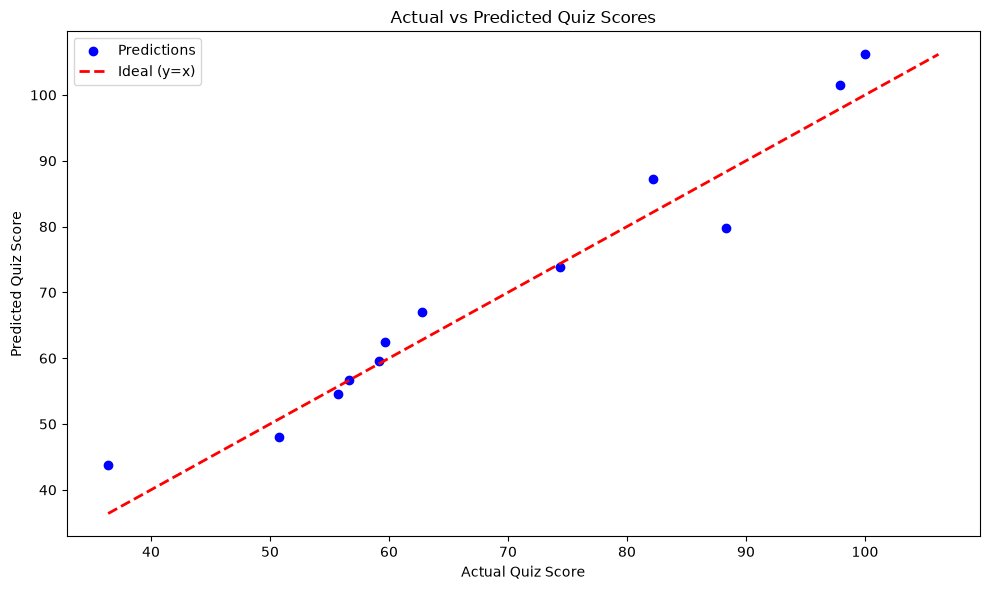

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_LR, color='blue', label='Predictions')
min_val = min(min(y_test), min(y_pred_LR))
max_val = max(max(y_test), max(y_pred_LR))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal (y=x)')

plt.xlabel('Actual Quiz Score')
plt.ylabel('Predicted Quiz Score')
plt.title('Actual vs Predicted Quiz Scores')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
for feature, coef in zip(X.columns, model_LR.coef_):
    print(f"{feature:20s}: {coef:.4f}")
print(f"{'Intercept':20s}: {model_LR.intercept_:.4f}")

study_hours         : 4.5635
videos_watched      : 0.7350
practice_solved     : 0.5860
Intercept           : 21.4031
